In [5]:
# Load the first time series response = 
from io import BytesIO
import numpy as np
import requests


response = requests.get("https://zenodo.org/records/10951538/files/arma_ts3.npz?download=1") 
response.raise_for_status() 
ts1 = np.load(BytesIO(response.content))['signal']
print(len(ts1))

response = requests.get("https://zenodo.org/records/10951538/files/arma_ts4.npz?download=1") 
response.raise_for_status() 
ts2 = np.load(BytesIO(response.content))['signal']
print(len(ts2))

479
1000


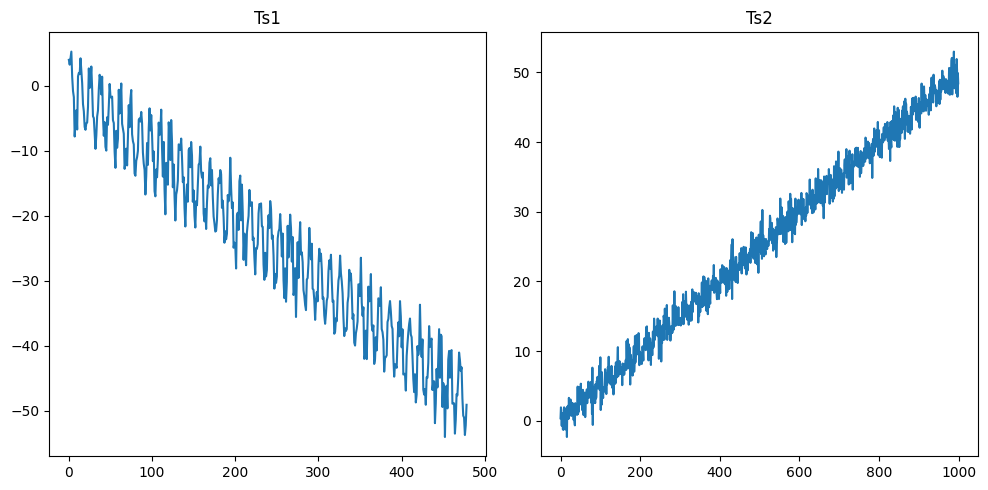

In [6]:
from matplotlib import pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(ts1)
plt.title("Ts1")
plt.subplot(1,2,2)
plt.plot(ts2)
plt.title("Ts2")
plt.tight_layout()

Text(0.5, 1.0, 'ts2 diff')

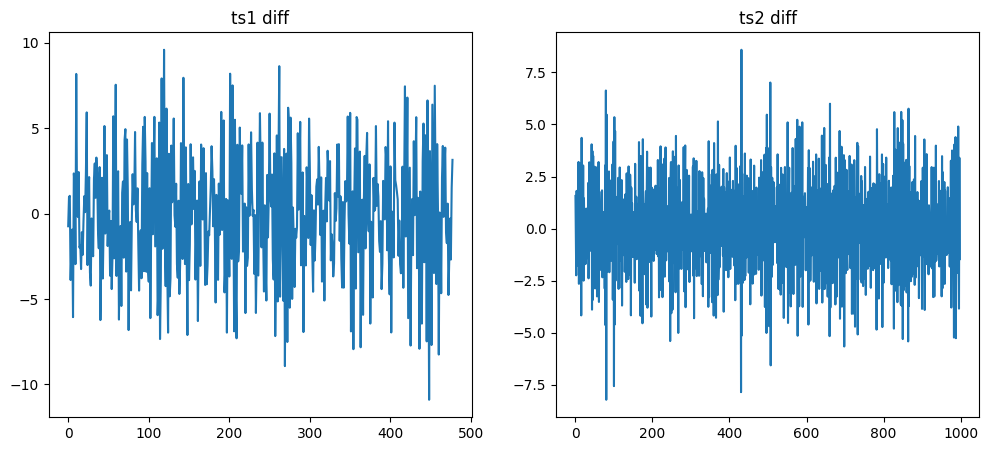

In [ ]:
# сделаем ряды стационарными через диффиренцирование
ts1_diff = np.diff(ts1)
ts2_diff = np.diff(ts2)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ts1_diff)
plt.title("ts1 diff")
plt.subplot(1,2,2)
plt.plot(ts2_diff)
plt.title("ts2 diff")

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf

def plot_ar_order_determination(data, lags=40, series_name="Time Series Data"):
    """
    Plots the Partial Autocorrelation Function (PACF) to help determine the 
    order (p) for an Autoregressive (AR) model.
    
    Args:
        data (np.ndarray or pd.Series): The time series data. 
                                        *Must be stationary (no trend/seasonality).*
        lags (int): The number of lags to plot.
        series_name (str): A title for the plot.
    """
    
    # CRITICAL: AR models assume stationarity. We must remove trend/seasonality first.
    # We use differencing as a quick method as discussed earlier.
    if isinstance(data, np.ndarray):
        data = pd.Series(data)
        
    # We apply a single difference to remove a linear trend
    stationary_data = data.diff().dropna()

    plt.figure(figsize=(15, 5))
    # 'ols' (Ordinary Least Squares) is a common method for PACF calculation
    plot_pacf(stationary_data, lags=lags, method='ols', title=f'Partial Autocorrelation Function (PACF) for {series_name}')
    
    plt.xlabel('Lags (p)')
    plt.ylabel('Partial Autocorrelation')
    plt.grid(True, alpha=0.3)
    plt.show()


<Figure size 1500x500 with 0 Axes>

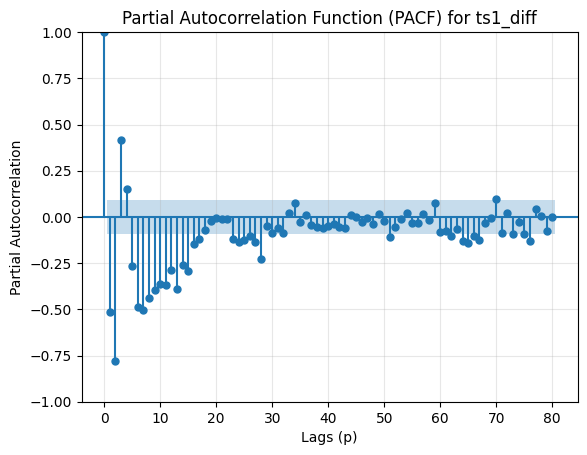

<Figure size 1500x500 with 0 Axes>

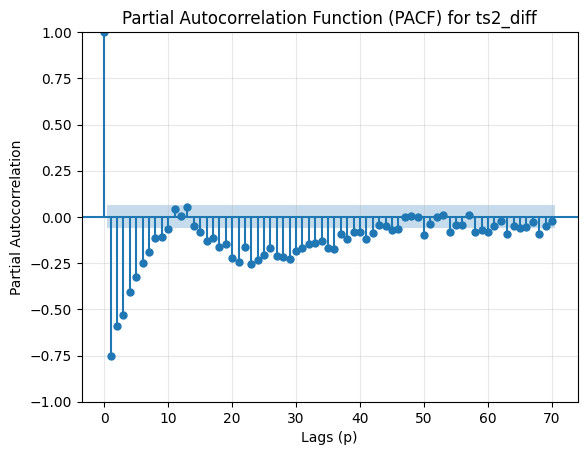

In [53]:
plot_ar_order_determination(ts1_diff, lags=80, series_name="ts1_diff")
plot_ar_order_determination(ts2_diff, lags=70, series_name="ts2_diff")

In [ ]:
# Для ряда ts1_diff кол-во лагов примерно ~ 27, AR(p)=27
# Для ряда ts2_diff кол-во лагов примерно ~ 170, AR(p)=170

--- Результаты прогноза ---
Mean Squared Error (MSE): **5.1262**


/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


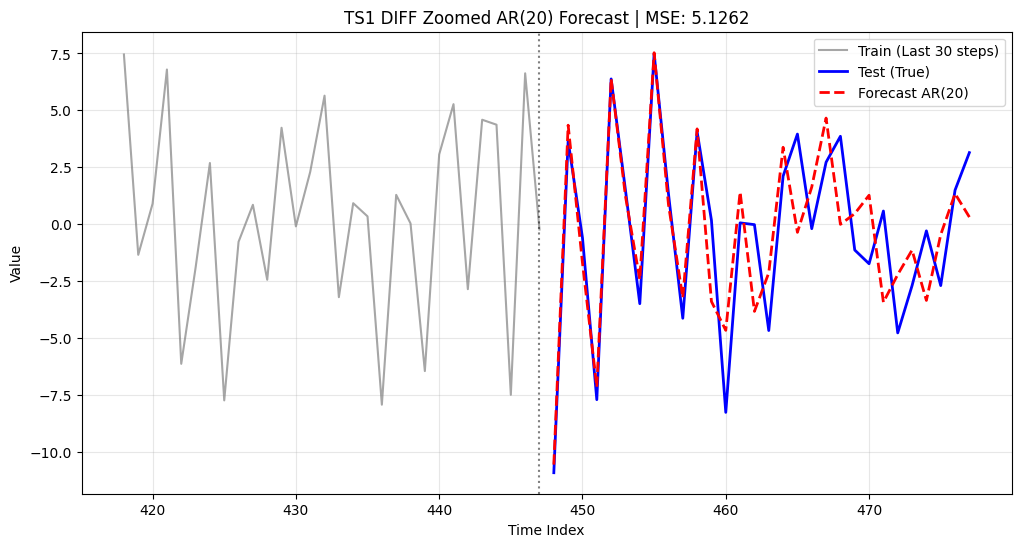

/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


--- Результаты прогноза ---
Mean Squared Error (MSE): **8.1276**


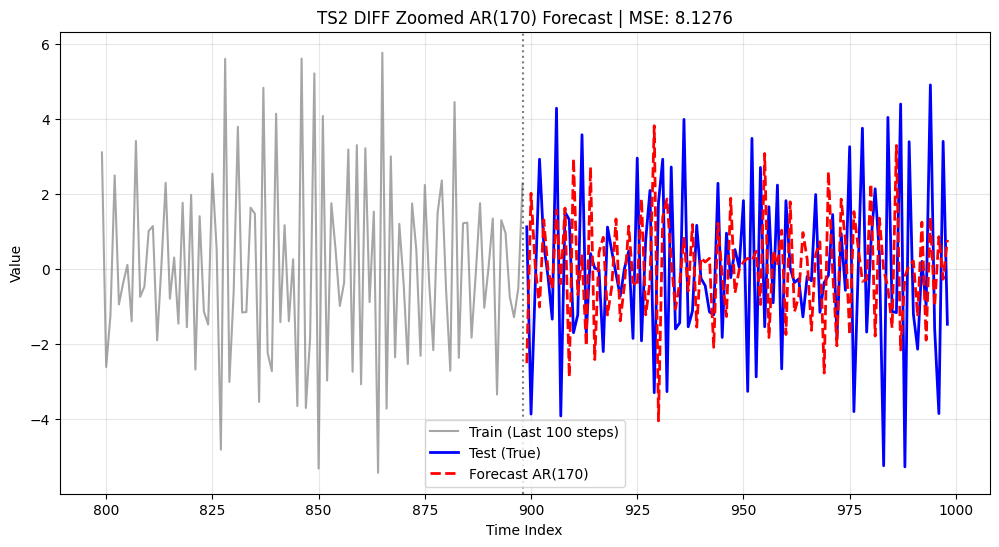

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
def forecast_ar_model_with_plot(train: np.ndarray, test: np.ndarray, p_lags: int,title=""):
    # 1. Stationary transformation
    if not isinstance(train, pd.Series):
        train = pd.Series(train)
        
    train_stationary = train.diff().dropna()
    N = len(train)
    K = len(test)
    
    # 2. Model Training
    model = AutoReg(train_stationary, lags=p_lags, seasonal=False, old_names=False)
    model_fit = model.fit()
    
    # 3. Forecast (stationary level)
    start_index = len(train_stationary)
    end_index = start_index + K - 1
    forecast_stationary = model_fit.predict(start=start_index, end=end_index)
    
    # 4. Invert differencing
    last_train_value = train.iloc[-1]
    forecast_original_scale = last_train_value + np.cumsum(forecast_stationary.values)

    # 5. MSE
    mse = mean_squared_error(test, forecast_original_scale)
    print(f"--- Результаты прогноза ---")
    print(f"Mean Squared Error (MSE): **{mse:.4f}**")
    
    # 6. Optimized Plotting
    plt.figure(figsize=(12, 6))
    
    # Indices for the "zoom" window
    train_slice_idx = np.arange(N - K, N)
    test_slice_idx = np.arange(N, N + K)

    # Plot only the last K elements of train
    plt.plot(train_slice_idx, train.iloc[-K:], label=f'Train (Last {K} steps)', color='gray', alpha=0.7)
    
    # Plot Test and Forecast
    plt.plot(test_slice_idx, test, label='Test (True)', color='blue', lw=2)
    plt.plot(test_slice_idx, forecast_original_scale, label=f'Forecast AR({p_lags})', color='red', linestyle='--', lw=2)
    
    # Visual alignment
    plt.axvline(x=N-1, color='black', linestyle=':', alpha=0.5) # Divider line
    plt.title(title+f" Zoomed AR({p_lags}) Forecast | MSE: {mse:.4f}")
    plt.xlabel("Time Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return forecast_original_scale

predicted_values_ar = forecast_ar_model_with_plot(
    train=ts1_diff[:-30], 
    test=ts1_diff[-30:], 
    p_lags=20,
    title="TS1 DIFF"
)

predicted_values_ar = forecast_ar_model_with_plot(
    train=ts2_diff[:-100], 
    test=ts2_diff[-100:], 
    p_lags=170,
    title="TS2 DIFF"
)


/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


--- Результаты MA(20) ---
MSE: **7.7490**


/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


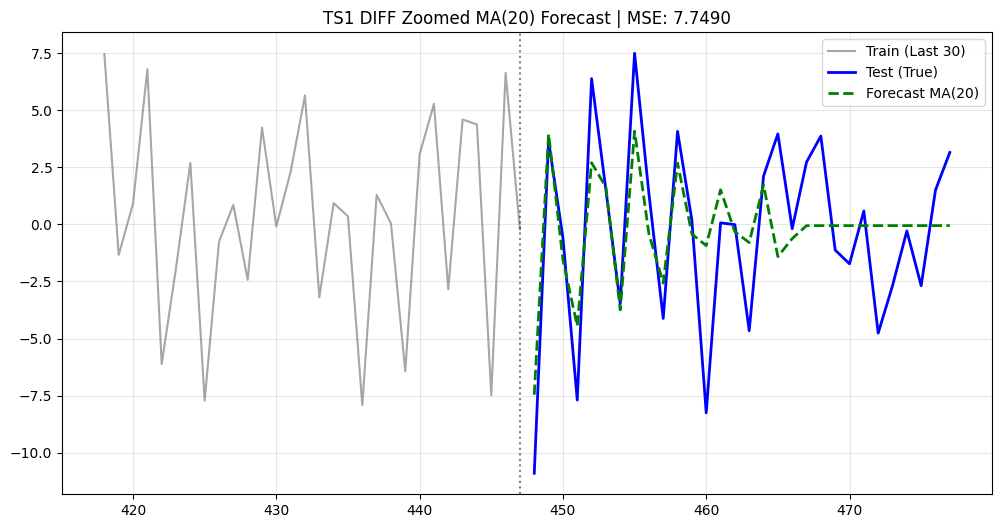

/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/vlad/Programs/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-i

--- Результаты MA(40) ---
MSE: **4.9818**


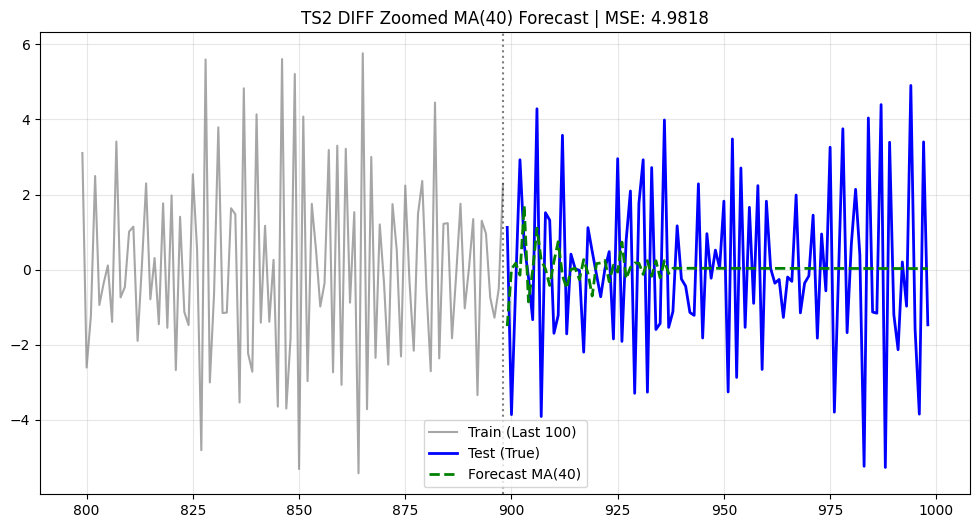

In [59]:
from statsmodels.tsa.arima.model import ARIMA
def forecast_ma_model_with_plot(train: np.ndarray, test: np.ndarray, q_lags: int, title=""):
    # 1. Приведение к Series и дифференцирование
    if not isinstance(train, pd.Series):
        train = pd.Series(train)
        
    train_stationary = train.diff().dropna()
    N, K = len(train), len(test)
    
    # 2. Обучение модели MA(q). В ARIMA порядок (p, d, q)
    # Используем (0, 0, q) для чистой модели скользящего среднего
    model = ARIMA(train_stationary, order=(0, 0, q_lags))
    model_fit = model.fit()
    
    # 3. Прогноз на K шагов вперед
    forecast_stationary = model_fit.forecast(steps=K)
    
    # 4. Обратное дифференцирование
    last_train_value = train.iloc[-1]
    forecast_original_scale = last_train_value + np.cumsum(forecast_stationary)

    # 5. MSE
    mse = mean_squared_error(test, forecast_original_scale)
    print(f"--- Результаты MA({q_lags}) ---")
    print(f"MSE: **{mse:.4f}**")
    
    # 6. Отрисовка (zoom-эффект: последние K значений train + прогноз)
    plt.figure(figsize=(12, 6))
    train_slice_idx = np.arange(N - K, N)
    test_slice_idx = np.arange(N, N + K)

    plt.plot(train_slice_idx, train.iloc[-K:], label=f'Train (Last {K})', color='gray', alpha=0.7)
    plt.plot(test_slice_idx, test, label='Test (True)', color='blue', lw=2)
    plt.plot(test_slice_idx, forecast_original_scale, label=f'Forecast MA({q_lags})', color='green', linestyle='--', lw=2)
    
    plt.axvline(x=N-1, color='black', linestyle=':', alpha=0.5)
    plt.title(f"{title} Zoomed MA({q_lags}) Forecast | MSE: {mse:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return forecast_original_scale


predicted_values_ar = forecast_ma_model_with_plot(
    train=ts1_diff[:-30], 
    test=ts1_diff[-30:], 
    q_lags=20,
    title="TS1 DIFF"
)

# 170 лагов считать очень долго, для теста я оставил 40
predicted_values_ar = forecast_ma_model_with_plot(
    train=ts2_diff[:-100], 
    test=ts2_diff[-100:], 
    q_lags=40,
    title="TS2 DIFF"
)
